<a href="https://colab.research.google.com/github/Prithujit-Ghosh/Dimensionality_Reduction_TMP/blob/main/PCA_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PCA Implementation**

**Notebook Structure:**

1. Importing Necessary Libraries

2. Importing The Dataset

3. Data Cleaning and Preprocessing

4. Initial Analysis

5. Data Quality Assessment
6. Univariate analysis of the numerical columns
7. Feature Scaling
8. PCA Implementation
9. Interpreting the PCA components
10. Visualizing the PCA components

**1. Importing Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Importing The Dataset**

In [ ]:
df_original=pd.read_csv("student_grades.csv")

**3. Data Cleaning and Preprocessing**

In [ ]:
#Checking for duplicate in the dataset
print(f"Number of duplicate entries: {df_original.duplicated().sum()}")

Number of duplicate entries: 0


In this case there are no duplicates in the dataset; treatment of duplicates is not required.

**4. Initial Analysis**

In [ ]:
df_original.shape

(100, 9)

In [ ]:
df_original.columns

Index(['student_id', 'math', 'science', 'cs', 'band', 'english', 'history',
       'spanish', 'physed'],
      dtype='object')

In [ ]:
df_original.head()

,student_id,math,science,cs,band,english,history,spanish,physed
0,1,46,48,50,74,34,44,39,73
1,2,66,65,65,66,74,80,75,63
2,3,55,53,50,76,71,72,76,71
3,4,53,57,53,80,77,77,85,82
4,5,55,62,58,67,82,77,78,60


In [ ]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  100 non-null    int64
 1   math        100 non-null    int64
 2   science     100 non-null    int64
 3   cs          100 non-null    int64
 4   band        100 non-null    int64
 5   english     100 non-null    int64
 6   history     100 non-null    int64
 7   spanish     100 non-null    int64
 8   physed      100 non-null    int64
dtypes: int64(9)
memory usage: 7.2 KB


**Classifying Variables:**

Numerical:  'math', 'science', 'cs', 'band', 'english', 'history',
       'spanish', 'physed'

Others: 'student_id'

**Dropping Redundant Columns:**

In [ ]:
df_or2=df_original.drop(columns=['student_id'])

In [ ]:
df_or2.head()

,math,science,cs,band,english,history,spanish,physed
0,46,48,50,74,34,44,39,73
1,66,65,65,66,74,80,75,63
2,55,53,50,76,71,72,76,71
3,53,57,53,80,77,77,85,82
4,55,62,58,67,82,77,78,60


In [ ]:
df_or2.columns

Index(['math', 'science', 'cs', 'band', 'english', 'history', 'spanish',
       'physed'],
      dtype='object')

**5. Data Quality Assessment**

In [ ]:
df_or2.isnull().sum()

,0
math,0
science,0
cs,0
band,0
english,0
history,0
spanish,0
physed,0


**Analysis**: The preceding results clearly states that there are no missing values.

**6. Univariate analysis of the numerical columns**

In [ ]:
df_or2.describe()

,math,science,cs,band,english,history,spanish,physed
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,53.050000,53.220000,52.750000,70.04000,60.970000,63.600000,65.560000,67.610000
std,13.912697,14.003304,13.462537,6.27794,17.307939,17.476102,18.405269,8.069014
min,21.000000,22.000000,28.000000,60.00000,30.000000,28.000000,31.000000,51.000000
25%,45.000000,44.750000,44.000000,64.00000,48.000000,50.750000,49.500000,62.750000
50%,51.500000,52.000000,50.000000,71.00000,60.500000,65.000000,68.500000,67.000000
75%,58.000000,59.250000,58.250000,75.00000,74.000000,78.000000,79.000000,74.250000
max,93.000000,94.000000,92.000000,80.00000,90.000000,98.000000,99.000000,84.000000


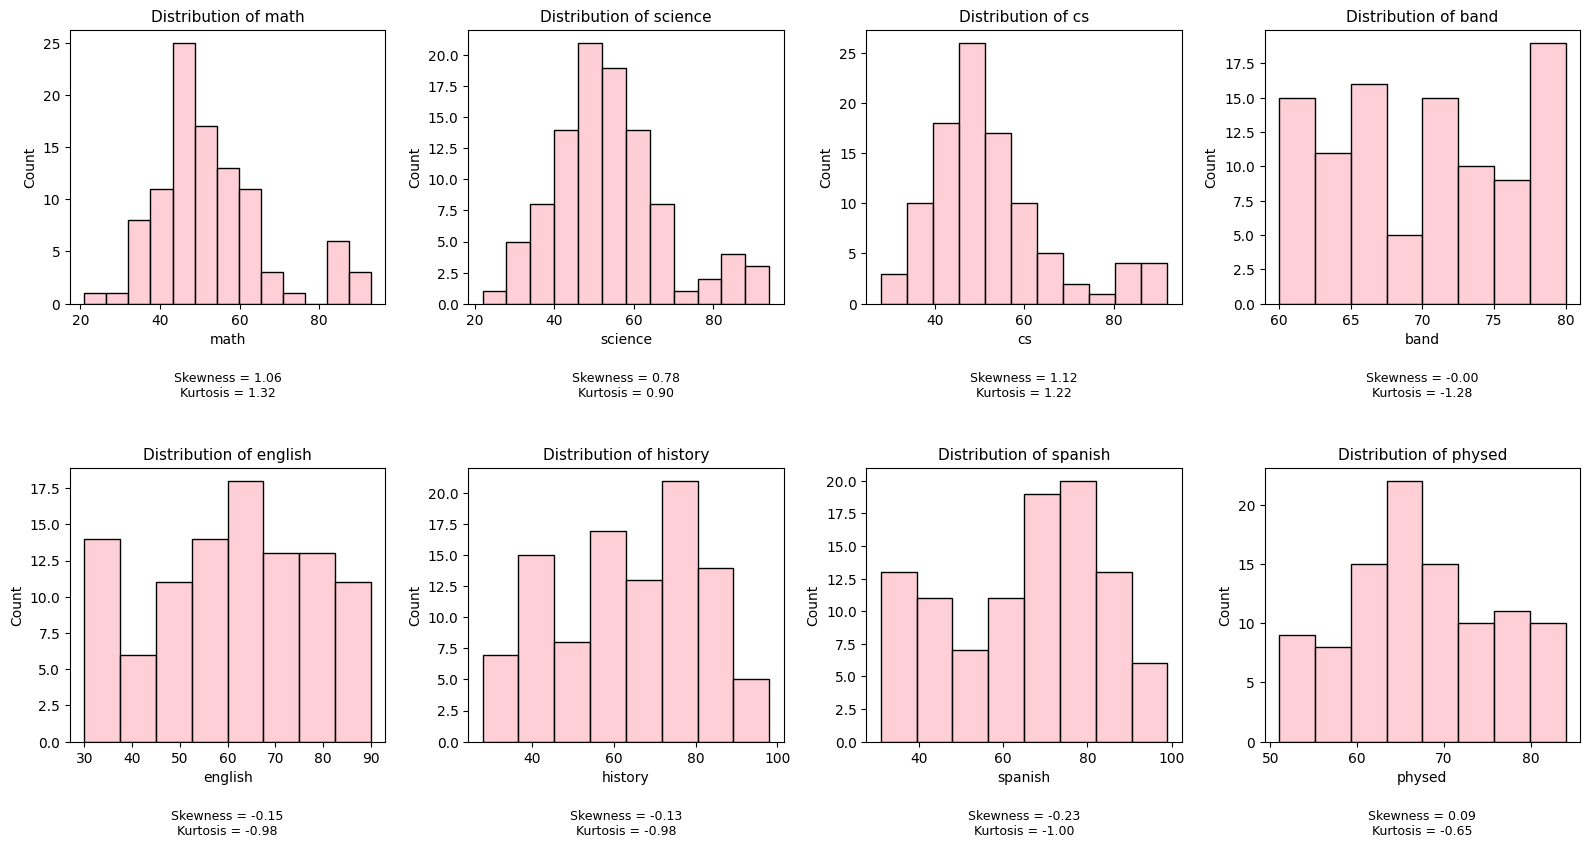

In [ ]:
features_to_check = ['math', 'science', 'cs', 'band', 'english', 'history', 'spanish',
       'physed']
plt.figure(figsize=(16, 12))

for i, col in enumerate(features_to_check):
    ax = plt.subplot(3, 4, i + 1)  # Create subplot

    # Plot histogram
    sns.histplot(data=df_or2, x=col, color="pink", ax=ax)

    # Calculate skewness & kurtosis
    skew_val = df_or2[col].skew()
    kurt_val = df_or2[col].kurt()

    # Add caption below each subplot
    ax.text(0.5, -0.25, f"Skewness = {skew_val:.2f}\nKurtosis = {kurt_val:.2f}",
            transform=ax.transAxes,
            ha="center", va="top", fontsize=9, color="black")

    # Title for each subplot
    ax.set_title(f'Distribution of {col}', fontsize=11)

# Adjust layout to make space for captions
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)  # More vertical space

plt.show()

##**Insights**
####**Subject Difficulty & Performance Buckets:**
The subjects clearly divide into three distinct performance groups based on their means and distributions:

**The "Hard" Subjects (STEM):** Math, Science, and CS have the lowest averages (approx. 52-53). These distributions are right-skewed (positive skewness), meaning most students scored on the lower end, with only a few high-achievers pulling the mean up.

**The "Middle" Subjects (Humanities)**: English, History, and Spanish show moderate performance with means between 59 and 66. These are slightly left-skewed (negative skewness), suggesting that more students are scoring above the average than below it.

**The "High-Success" Subjects:** Band and PhysEd have the highest averages (70 and 67 respectively). These subjects also have the lowest standard deviations, meaning student performance is more consistent and "grouped" together compared to the wide variety of scores in English or History.

####**Distribution Analysis (Kurtosis & Skew):**
**STEM Peakiness (Leptokurtic):** Math and CS have positive Kurtosis (1.32 and 1.22). This tells us that the scores are heavily concentrated around a specific "average" point with infrequent extreme outliers. It suggests a very standardized level of difficulty where most students hit a "ceiling" or "floor" together.

**The Humanities Gap:** English, History, and Spanish have negative Kurtosis (around -1.0). These distributions are flatter (Platykurtic). This indicates there isn't one "common" grade; instead, students are spread out across a wide range of scores, possibly indicating that these subjects depend more on individual student effort or interest.

**The Band Ceiling:** Band has a Kurtosis of -1.28 and a maximum score of 80 (the lowest "Max" of any subject). This suggests the grading might be capped or the curriculum is designed so that almost everyone reaches a high level of competency but nobody "breaks away" with a 90+.

**7. Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler_ft = scaler.fit_transform(df_or2)
df_scaled = pd.DataFrame(scaler_ft, columns=df_or2.columns)
df_scaled.head()

,math,science,cs,band,english,history,spanish,physed
0,-0.509284,-0.374647,-0.205300,0.633958,-1.566095,-1.127182,-1.450335,0.671353
1,0.935494,0.845468,0.914517,-0.646765,0.756626,0.943152,0.515480,-0.574200
2,0.140866,-0.015790,-0.205300,0.954139,0.582422,0.483078,0.570086,0.422242
3,-0.003612,0.271296,0.018664,1.594500,0.930830,0.770624,1.061540,1.792350
4,0.140866,0.630154,0.391936,-0.486675,1.221171,0.770624,0.679298,-0.947865


**8. PCA Implementation**

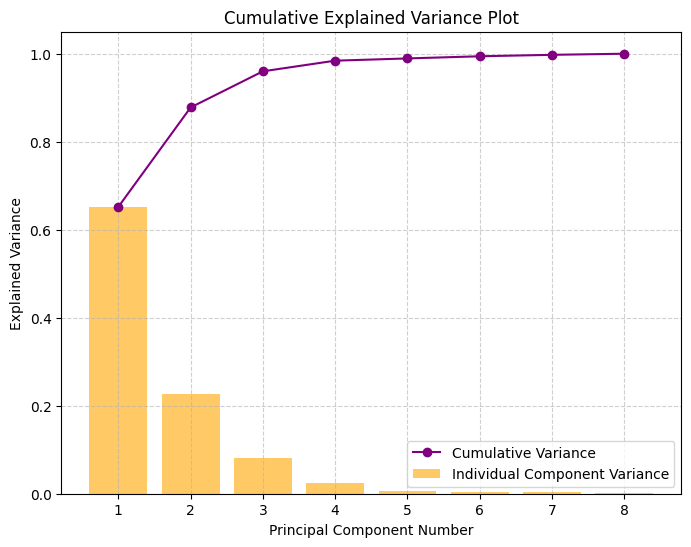

In [ ]:
from sklearn.decomposition import PCA

# Run PCA with all 8 components
pca = PCA(n_components=8)
pca.fit(df_scaled)

# Explained variance ratio for each component
explained_var_ratio = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_var_ratio = np.cumsum(explained_var_ratio)

# Plot
plt.figure(figsize=(8,6))

# Orange bars: individual component variance
plt.bar(range(1, 9), explained_var_ratio, alpha=0.6, color='orange',
        label='Individual Component Variance')

# Blue line: cumulative variance
plt.plot(range(1, 9), cumulative_var_ratio, marker='o', color='purple',
         label='Cumulative Variance')

plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance')
plt.title('Cumulative Explained Variance Plot')
plt.xticks(range(1, 9))
plt.ylim(0, 1.05)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
df_pca_info=pd.DataFrame({
    "Component":range(1,9),
    "Individual Component Vatiance": explained_var_ratio,
    "Cumulative Explained Variance": cumulative_var_ratio
})

In [ ]:
df_pca_info

,Component,Individual Component Vatiance,Cumulative Explained Variance
0,1,0.651987,0.651987
1,2,0.225910,0.877897
2,3,0.082115,0.960011
3,4,0.024182,0.984193
4,5,0.005090,0.989284
5,6,0.004905,0.994189
6,7,0.003321,0.997509
7,8,0.002491,1.000000


**9. Interpreting the PCA components**

Since, the cumulative explained variance of the first two components is approximately 88%,
Moving forward with only first two components.

In [ ]:
df_pca_components=pd.DataFrame(pca.components_,columns=df_scaled.columns,index=range(1,9))
df_pca_components.head(2)

,math,science,cs,band,english,history,spanish,physed
1,0.410679,0.410540,0.405460,-0.001911,0.406567,0.407957,0.405591,0.046562
2,0.009780,0.028735,0.027437,0.705642,-0.051722,-0.051628,-0.039960,0.702466


Here, each **row** represents a **Principal Component (PC)** and each **column** represents an **original feature**.
Each cell is populated by the weight of the corresponding column for the corresponding pricipal component.

###Analysing the First Principal Component:
[0.410679	0.410540	0.405460	-0.001911	0.406567	0.407957	0.405591	0.046562]


*   It has moderate weights (about 0.4) for all core subjects.
*   But it has very low weights for both "band" and "physed" (physical education).
*   **Significance:** This component seems to capture a contrast between performance core/traditional subjects and band/physical education. For example, if a student scores high on PC1, it means they are good at core subjects, and possibly less impressive at band/"physed".

###Analysing the Second Principal Component:
[0.009780	0.028735	0.027437	0.705642	-0.051722	-0.051628	-0.039960	0.702466]
*   It has very small weights (about 0.4) for all STEM subjects.
*   And even negative weights for languages/humanities.

*   But high positive weights for band/"physed".
*   **Significance:** If a student scores high on this, we can conclude that they are good at "band"/"physed" (have good artistic abilities or physical fitness) but may have poor performance it traditional subjects (especially in humanities and languages).





**10. Visualizing the PCA components**

 Transforming the data in lower dimention ( 2 dimention in our case )

In [ ]:
df_transformed=pd.DataFrame(pca.transform(df_scaled))
df_transformed=df_transformed.drop(range(2,8),axis=1)
df_transformed.columns=["pc1","pc2"]
df_transformed.head()

,pc1,pc2
0,-2.100960,1.094722
1,1.978045,-0.909630
2,0.651055,0.887337
3,1.321249,2.262133
4,1.518651,-1.109114


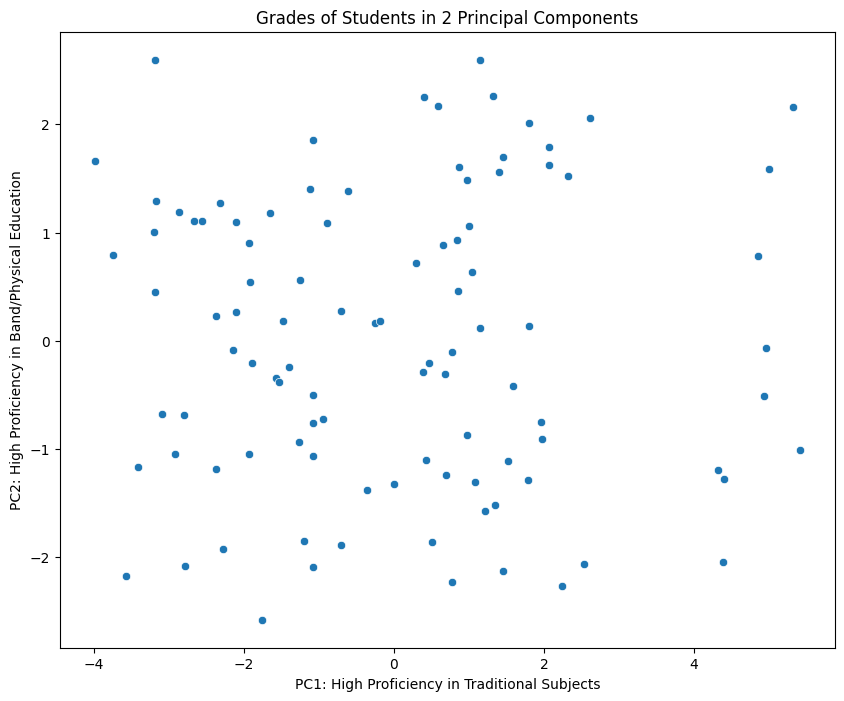

In [ ]:
# Creating a figure and axes with a specified size
plt.figure(figsize=(10, 8))
sns.scatterplot(x='pc1', y='pc2', data=df_transformed)

# Using descriptive lebels
plt.xlabel('PC1: High Proficiency in Traditional Subjects')
plt.ylabel('PC2: High Proficiency in Band/Physical Education')

plt.title('Grades of Students in 2 Principal Components')
plt.show()

**Insights drawn from the Plot:**


*   **Uniform Distribution:** There are Students of all levels and type of profiencies.
*   **Top-Right Quadrant (High PC1, High PC2):** This group of students are simultaneously good at both core subjectsand band/physical

*   **Bottom-Right Quadrant (High PC1, Low PC2):** Good at academics but poor at band/physical education.

    They are studious but less focused in other activities.
    Special programmes can be organized to increase their interests in these fields.

*   **Top-Left Quadrant (Low PC1, High PC2):** Good at physical activities or creativity but struggling with academics.
    Required extra attention for the betterment of academics.
*   **Bottom-Left Quadrant (Low PC1, Low PC2):** Poorly performing across both parameters.

    Special attention needed by teachers of all fields.


*   **A few High Achievers in Studies:** There are a few high performers in core subjects, although their excellence in Band/Physical Education varies significantly.

